In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA_ROOT = Path("../data")
IMAGES_DIR = DATA_ROOT / "images/train"
LABELS_DIR = DATA_ROOT / "labels/train"

# 0: flowar, 1: green, 2:pink, 3:blue
CLASS_NAMES = ["flower", "green", "pink", "blue"]
NUM_CLASSES = len(CLASS_NAMES)

Empty images represent negative samples!

QUESTIONS:
- Do empty images come from different  distribution (different fields) ?
- Are they over-represented relative to real-world deployment ?? (this will be an issue)

### Class distribution (global + per image)

Counter({1: 51533, 3: 3808, 2: 2624, 0: 34})


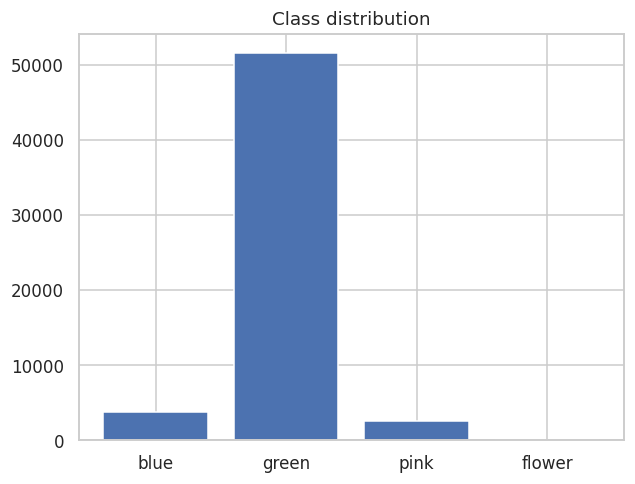

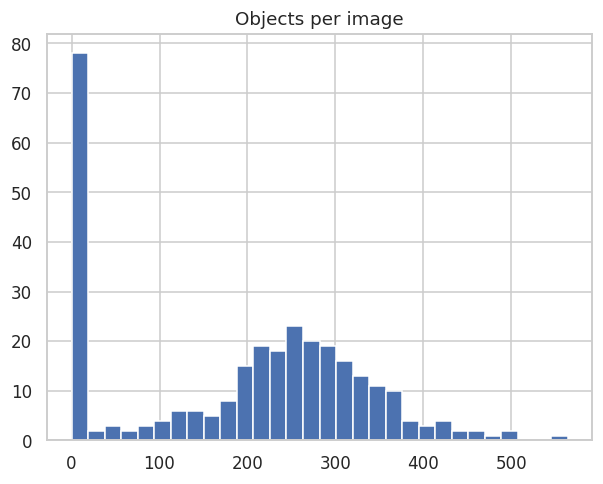

In [2]:
class_counts = Counter()
instances_per_image = []

# label_dir = "../data/labels/train"

# p = Path(label_dir)
for file in LABELS_DIR.iterdir():
  with file.open() as f:
    lines = f.readlines()
    instances_per_image.append(len(lines))
    for line in lines:
      cls = int(line.split()[0])
      class_counts[cls] += 1

print(class_counts)

# plot class imbalance
# plt.bar(class_counts.keys(), class_counts.values())
plt.bar(np.array(CLASS_NAMES)[list(class_counts.keys())], class_counts.values())
plt.title("Class distribution")
plt.show()

# Objects per image
plt.hist(instances_per_image, bins=30)
plt.title("Objects per image")
plt.show()

### Bounding Boxes size distribution

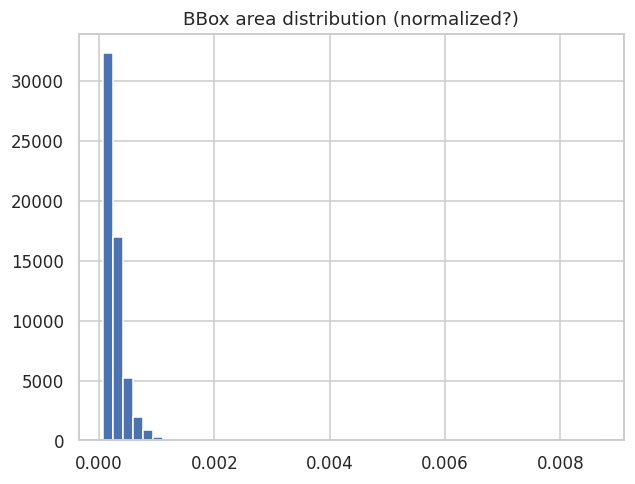

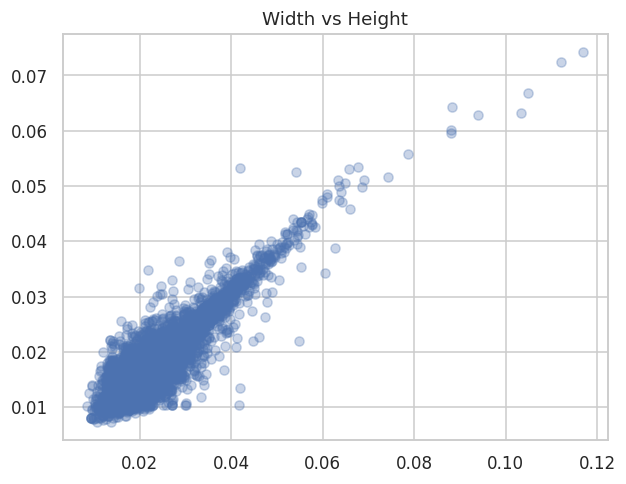

In [3]:
areas = []
widths = []
heights = []

for file in LABELS_DIR.iterdir():
  with file.open() as f:
    for line in f:
      _, _, _, w, h = map(float, line.split())
      widths.append(w)
      heights.append(h)
      areas.append(w*h)
      
plt.hist(areas, bins=50)
plt.title("BBox area distribution (normalized?)")
plt.show()

plt.scatter(widths, heights, alpha=0.3)
plt.title("Width vs Height")
plt.show()

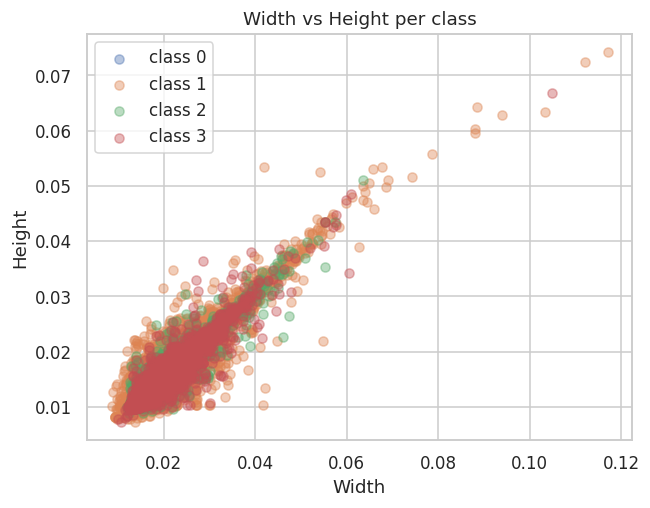

In [4]:
widths = []
heights = []
classes = []

for file in LABELS_DIR.iterdir():
  with file.open() as f:
    for line in f:
      cls, _, _, w, h = map(float, line.split())
      widths.append(w)
      heights.append(h)
      classes.append(int(cls))
      
# scatter = plt.scatter(widths, heights, c=classes, cmap="tab10", alpha=0.3)
# plt.colorbar(scatter, label="Class")
# plt.title("Width vs Height")
# plt.show()

classes_np = np.array(classes)
widths_np = np.array(widths)
heights_np = np.array(heights)

plt.figure()

for cls in np.unique(classes_np):
    mask = classes_np == cls
    plt.scatter(
        widths_np[mask],
        heights_np[mask],
        alpha=0.4,
        label=f"class {cls}"
    )

plt.legend()
plt.title("Width vs Height per class")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

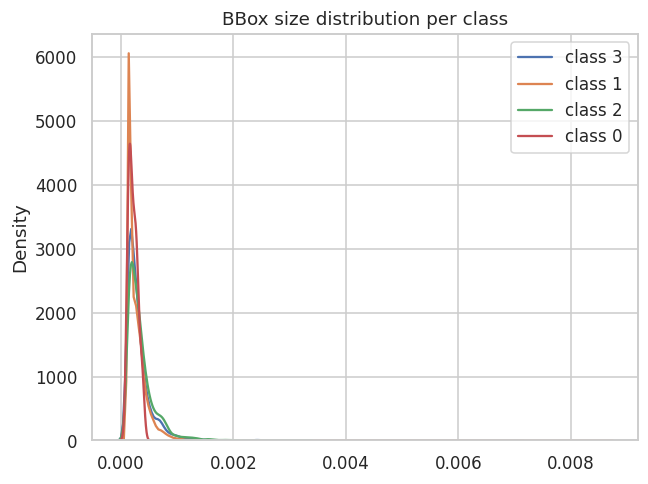

In [5]:
import seaborn as sns

class_areas = dict()

for file in LABELS_DIR.iterdir():
  with file.open() as f:
    for line in f:
      cls, _, _, w, h = map(float, line.split())
      class_areas.setdefault(int(cls), []).append(w*h)


for cls, vals in class_areas.items():
  sns.kdeplot(vals, label=f"class {cls}", multiple="layer")

plt.legend()
plt.title("BBox size distribution per class")
plt.show()


### Spatial heatmap of object locations

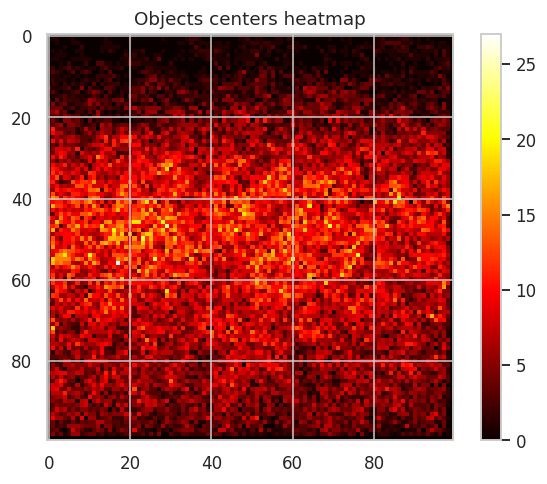

In [6]:
heatmap = np.zeros((100, 100))

for file in LABELS_DIR.iterdir():
  with file.open() as f:
    for line in f:
      _, x, y, _, _ = map(float, line.split())
      xi, yi = int(x*99), int(y*99)
      heatmap[yi, xi] += 1

plt.imshow(heatmap, cmap="hot")
plt.colorbar()
plt.title("Objects centers heatmap")
plt.show()

### Image level color distribution

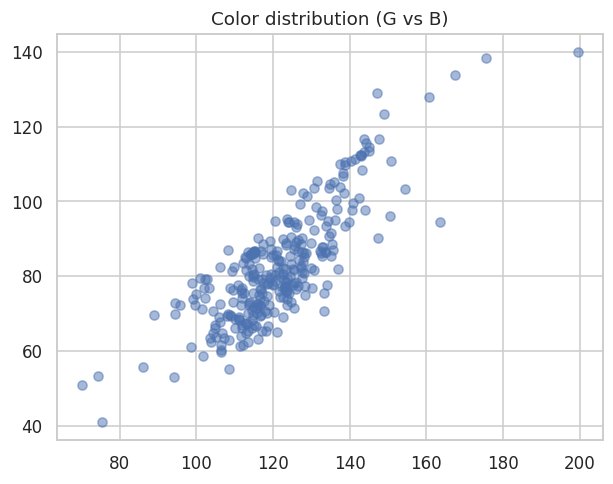

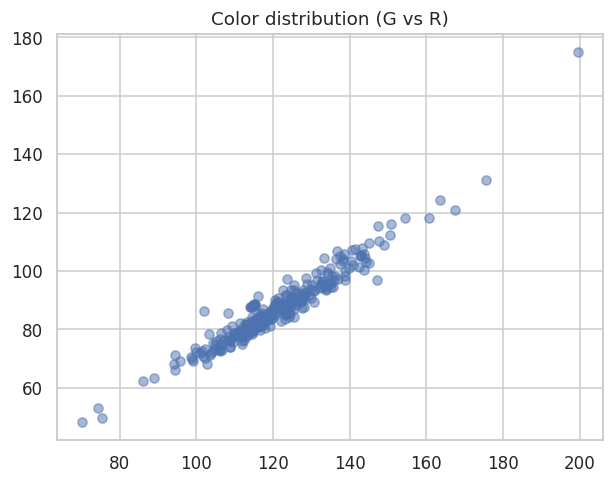

In [8]:
import cv2

means = []

for file in IMAGES_DIR.iterdir():
  img = cv2.imread(file) # 2048 x 1536 x 3
  means.append(img.mean(axis=(0,1))) # avg color

means = np.array(means) # avg colors per image

plt.scatter(means[:,1], means[:,0], alpha=0.5)
plt.title("Color distribution (G vs B)")
plt.show()
plt.scatter(means[:,1], means[:,2], alpha=0.5)
plt.title("Color distribution (G vs R)")
plt.show()

### Crops exploration

In [ ]:
import hashlib
from itertools import islice
import torch
from torchvision.utils import draw_bounding_boxes
from torchvision.io import decode_image
import torchvision.transforms.functional as F
plt.rcParams["savefig.bbox"] = "tight"

def class_to_color(class_name: str):
  h = hashlib.md5(class_name.encode()).hexdigest()
  return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

img = decode_image("../data/images/train/c834a7b7-4bbd-4791-98c0-9d2d8123d60a_L_00000189.png")

for file in islice(LABELS_DIR.iterdir(), 1):
  img = decode_image((IMAGES_DIR / file.stem).with_suffix(".png")) # 3x2048x1536
  img_h, img_w = img.shape[1:]
  print(img_h, img_w)
  # print(img.dtype)
  # print(img.min(), img.max())

  with file.open() as f:
    lines = f.readlines()
    boxes = []
    labels = [] # class name per box
    for line in lines:
      cls, xc, yc, bw, bh = map(float, line.split())

      x1 = (xc - bw/2) * img_w # x_min
      y1 = (yc - bh/2) * img_h # y_min
      x2 = (xc + bw/2) * img_w # x_max
      y2 = (yc + bh/2) * img_h # y_max
      boxes.append((x1, y1, x2, y2))
      labels.append(CLASS_NAMES[int(cls)])

  colors = [class_to_color(l) for l in labels]
  # result = draw_bounding_boxes(img, torch.tensor(boxes), labels=labels, colors="red", width=4, font="DejaVuSans.ttf",font_size=10)
  result = draw_bounding_boxes(img, torch.tensor(boxes), labels=labels, colors=colors, width=4, font_size=10)
  print(result.shape)
  fig, ax = plt.subplots(figsize=(16, 8))
  ax.imshow(F.to_pil_image(result))
  ax.axis('off')
  plt.show()

  # plot crop
  x1 = int(round(x1))
  y1 = int(round(y1))
  x2 = int(round(x2))
  y2 = int(round(y2))
  print(y1, y2, x1, x2)
  crop = img[:, y1:y2, x1:x2]

  plt.imshow(F.to_pil_image(crop))
  plt.show()


Found 17 boxes for class blue


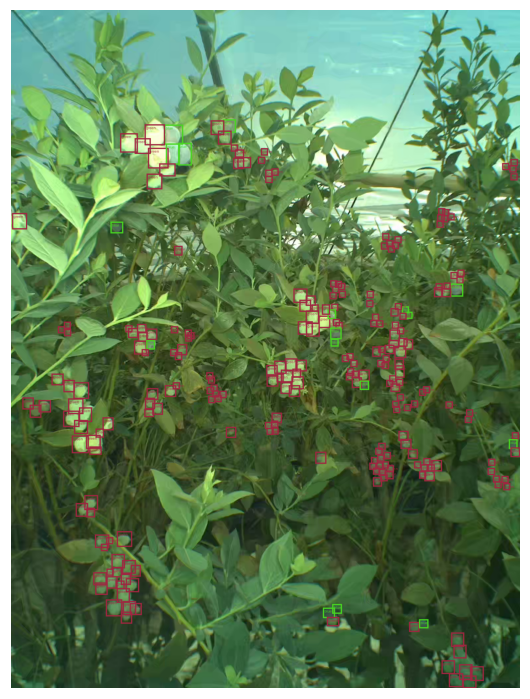

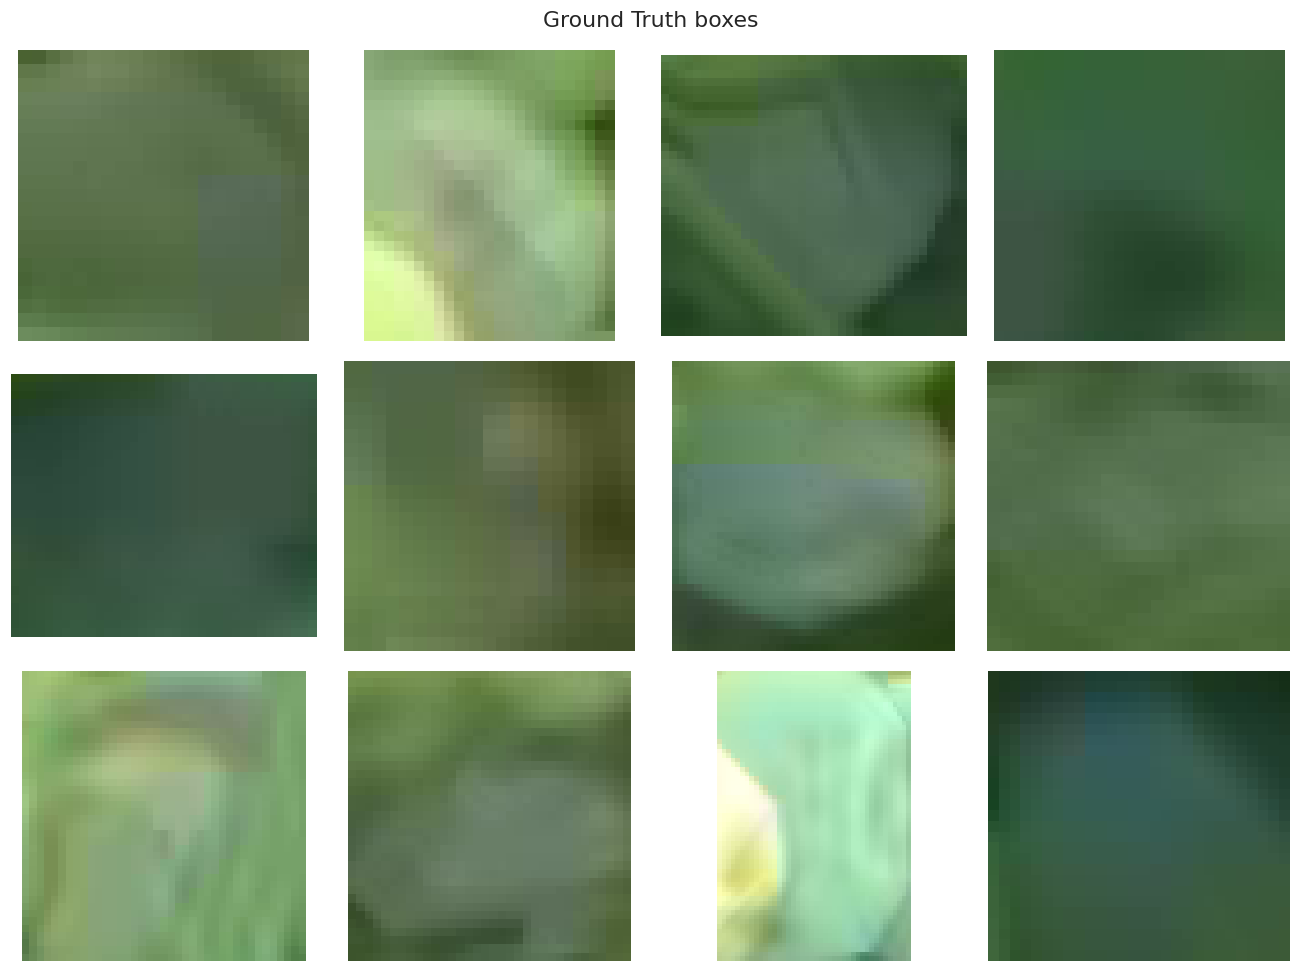

Found 33 boxes for class blue


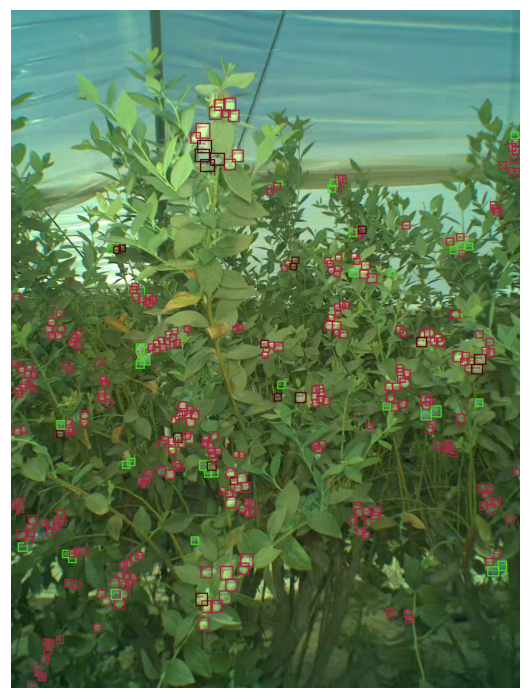

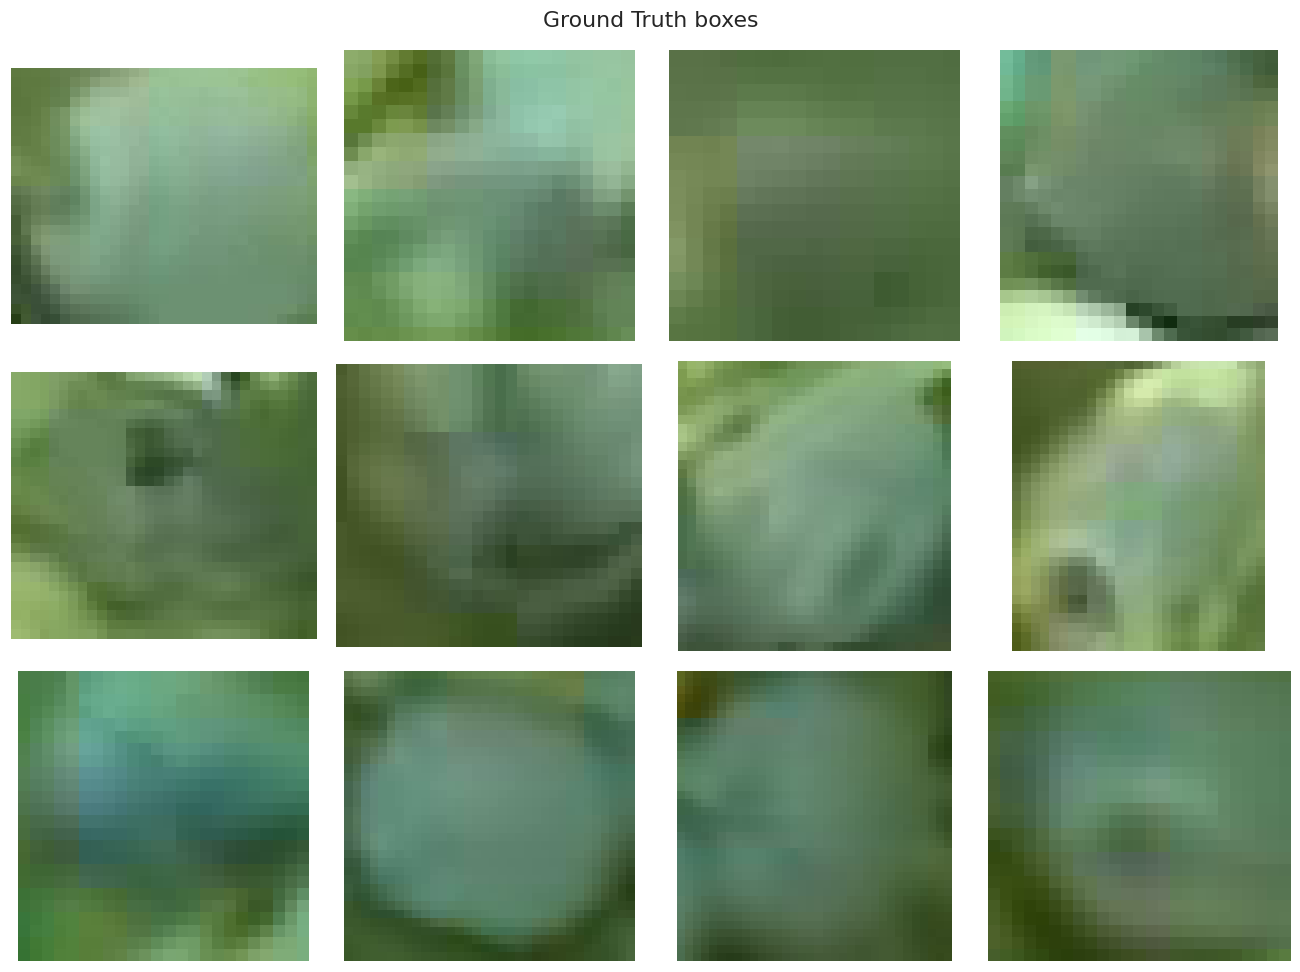

In [ ]:
from dataclasses import dataclass
import hashlib
from itertools import islice
import torch
from torchvision.utils import draw_bounding_boxes
from torchvision.io import decode_image
import torchvision.transforms.functional as F
plt.rcParams["savefig.bbox"] = "tight"

NUM_CROPS_TO_PLOT = 5
PLOT_CLASS = "blue"

@dataclass
class BBox:
  cls: int # index
  cls_name: str
  xc: float # normalized
  yc: float
  w: float
  h: float

  def to_xyxy(self, img_h, img_w) -> tuple[int, int, int, int]:
    x1 = (self.xc - self.w/2) * img_w # x_min
    y1 = (self.yc - self.h/2) * img_h # y_min
    x2 = (self.xc + self.w/2) * img_w # x_max
    y2 = (self.yc + self.h/2) * img_h # y_max
    return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))


def class_to_color(class_name: str):
  h = hashlib.md5(class_name.encode()).hexdigest()
  return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

def show(img: torch.Tensor, boxes: list[BBox]):
  '''
  img: uint8 CxHxW [0, 255] torch.Tensor
  '''
  draw_boxes = []
  labels = []
  for bbox in boxes:
    x1, y1, x2, y2 = bbox.to_xyxy(img.shape[1], img.shape[2])
    draw_boxes.append((x1, y1, x2, y2))
    labels.append(bbox.cls_name)

  draw_boxes = torch.tensor(draw_boxes)
  colors = list(map(class_to_color, labels)) # [class_to_color(l) for l in labels]

  # drawn_img = draw_bounding_boxes(img, draw_boxes, labels=labels, colors=colors, width=4, font_size=10)
  drawn_img = draw_bounding_boxes(img, draw_boxes, labels=labels, colors=colors, width=4)
  # print(result.shape)
  fig, ax = plt.subplots(figsize=(16, 8))
  # ax.imshow(F.to_pil_image(result))
  ax.imshow(drawn_img.permute(1,2,0))
  ax.axis('off')
  plt.show()

def plot_crops(img: torch.Tensor, boxes: list[BBox], plot_class=None):
  '''
  plot_class: the name of the class to plot crops from.. 
  '''
  labels = []
  draw_boxes = []
  for bbox in boxes:
    x1, y1, x2, y2 = bbox.to_xyxy(img.shape[1], img.shape[2])
    draw_boxes.append((x1, y1, x2, y2))
    labels.append(bbox.cls_name)

  if plot_class:
    print(f"{NUM_CROPS_TO_PLOT} samples from {plot_class}")
    for i in range(NUM_CROPS_TO_PLOT):
      if labels[i] == plot_class:
        x1, y1, x2, y2 = draw_boxes[i]
        crop = img[:, y1:y2, x1:x2]
        plt.imshow(crop.permute(1,2,0))
        plt.show()
  
def extract_class_crops(img: torch.Tensor, boxes: list[BBox], target_class: str):
  '''
  return only the crops that correspond to the specified class
  '''
  img_h, img_w = img.shape[1:]
  crops = []
  for box in boxes:
    if box.cls_name != target_class:
      continue

    x1, y1, x2, y2 = box.to_xyxy(img_h, img_w)
    crop = img[:, y1:y2, x1:x2]  
    crops.append(crop)

  return crops


def show_crops(crops, max_n = 12):
  '''
  crops: list with CxHxW cropped detection patches extracted from the img
  '''
  n = min(len(crops), max_n)
  cols = 4
  rows = (n + cols -1) // cols

  fig, ax = plt.subplots(rows, cols, figsize=(12, 3*rows))
  ax = ax.flatten()

  for i in range(len(ax)):
    ax[i].axis('off')

  for i in range(len(ax)):
    ax[i].imshow(crops[i].permute(1,2,0))

  plt.suptitle("Ground Truth boxes")
  plt.tight_layout()
  plt.show()

    
def parse_img_label(img_path: Path, label_path: Path) -> tuple[torch.Tensor, list[BBox]]:
  img = decode_image(img_path) # uint8 [0, 255], CxHxW
  # print(img.size())
  img_h, img_w = img.shape[1:]

  draw_boxes: list[tuple] = []
  boxes: list[BBox] = []
  with label_path.open(encoding='utf-8') as f:
    for line in f:
      cls, cx, cy, w, h = map(float, line.split())
      cls = int(cls)
      cls_name = CLASS_NAMES[cls]
      bbox = BBox(cls, cls_name,cx,cy,w,h)
      boxes.append(bbox)

  # print(boxes)
  # show(img, boxes)
  # plot_crops(img, boxes, PLOT_CLASS)
  return img, boxes

for label_path in islice(LABELS_DIR.iterdir(), 0, 3):
  img_path = (IMAGES_DIR / label_path.stem).with_suffix(".png")
  img, boxes = parse_img_label(img_path, label_path)

  crops = extract_class_crops(img, boxes, PLOT_CLASS)

  if len(crops) != 0:
    print(f"Found {len(crops)} boxes for class: {PLOT_CLASS}")
    show(img, boxes)
    show_crops(crops)


## Observations

- A Crop with blue background (sky) has the same amoount of blue as a 'blue' crop.. -> That would be a problem even for a dedicated classifier per box, let alone for a YOLO-like model